In [1]:
import os
import string
from pathlib import Path
from tqdm.auto import tqdm, trange
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, Counter
import numpy as np
import pickle
import matplotlib
import hdbscan
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from matplotlib.markers import MarkerStyle
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.express as px
from matplotlib.colors import ListedColormap
from itertools import groupby
from matplotlib import colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from enzymeexplorer.src.structure_processing.structural_algorithms import MappedRegion
from enzymeexplorer.src.data_preparation.utils import preprocess_martsdb
import warnings

In [2]:
def get_reaction_type(tps_type, original_type, tps_class, original_type_2_class):
    type_correction = {"pt": "isoprenyl diphosphate synthase", "sesq": "sesqui"}
    corrected_type = type_correction.get(tps_type, tps_type)

    if tps_type in {"tri", "tetra"}:
        if original_type == "sqs":
            return f"{corrected_type} (squalene synthase)"
        elif original_type == "psy":
            return f"{corrected_type} (phytoene synthase)"

    if len(original_type_2_class[tps_type]) == 1:
        return corrected_type
    elif len(original_type_2_class[tps_type]) > 1:
        return f"{corrected_type} (Class {tps_class})"
    return False


def _default_group_key(label: str) -> str:
    return label.split()[0] if label.strip() else ""


def build_label_color_mapping_reserved_hue(
    reaction_types,
    group_key_fn=None,
    *,
    base_s=0.85,
    base_v=0.85,
    # hard constraints
    min_group_sep=0.06,  # minimum hue distance between group base hues (0..1)
    safety=0.45,  # fraction of neighbor gap reserved for within-group tones
    max_intragroup_span=0.20,  # cap, in case gaps are huge
    seed=0,
):
    """
    Guarantees:
      - Each group has a distinct base hue.
      - Within-group hues lie inside a reserved interval around the base hue that
        does not overlap neighboring groups' reserved intervals (by construction).
    """
    if group_key_fn is None:
        group_key_fn = _default_group_key

    # group labels
    group_to_labels = {}
    for lab in reaction_types:
        g = group_key_fn(lab)
        group_to_labels.setdefault(g, []).append(lab)

    for g in group_to_labels:
        group_to_labels[g] = sorted(group_to_labels[g])
    groups = sorted(group_to_labels.keys())
    n_groups = len(groups)
    if n_groups == 0:
        return {}, {}

    # --- propose base hues via golden-ratio stepping ---
    phi = 0.618033988749895
    rng = np.random.default_rng(seed)
    h0 = float(rng.random())

    base_hues = []
    h = h0
    for _ in range(n_groups):
        base_hues.append(h % 1.0)
        h += phi

    # --- enforce minimum separation (simple rejection/adjustment) ---
    # For typical n_groups <= ~15 and min_group_sep ~0.06, this is fine.
    # If too many groups for the requested min_sep, we relax min_sep automatically.
    max_possible_sep = 1.0 / n_groups
    if min_group_sep > max_possible_sep:
        min_group_sep = 0.9 * max_possible_sep  # best-effort

    def circular_dist(a, b):
        d = abs(a - b) % 1.0
        return min(d, 1.0 - d)

    # small iterative "jitter" to reduce near-collisions
    base_hues = np.array(base_hues, dtype=float)
    for _ in range(2000):
        ok = True
        for i in range(n_groups):
            for j in range(i + 1, n_groups):
                if circular_dist(base_hues[i], base_hues[j]) < min_group_sep:
                    ok = False
                    # push j slightly
                    base_hues[j] = (base_hues[j] + min_group_sep) % 1.0
        if ok:
            break

    # Map group -> base hue (keep group order stable but base hues are as constructed)
    group_to_base_h = {g: float(h) for g, h in zip(groups, base_hues.tolist())}

    # --- reserve a non-overlapping hue interval per group ---
    # Work on sorted-by-hue groups to compute neighbor gaps
    sorted_pairs = sorted(group_to_base_h.items(), key=lambda kv: kv[1])
    sorted_groups = [g for g, _ in sorted_pairs]
    sorted_hues = np.array([h for _, h in sorted_pairs], dtype=float)

    # circular gaps between consecutive base hues
    gaps = np.diff(np.r_[sorted_hues, sorted_hues[0] + 1.0])  # size n_groups
    # each group can use at most safety * min(left_gap, right_gap)
    # left_gap for i is gaps[i-1], right_gap is gaps[i]
    left_gaps = np.r_[gaps[-1], gaps[:-1]]
    right_gaps = gaps
    min_neighbor_gap = np.minimum(left_gaps, right_gaps)

    group_to_span = {}
    for g, h, mg in zip(sorted_groups, sorted_hues, min_neighbor_gap):
        span = min(max_intragroup_span, safety * mg)
        # ensure non-zero span if a group has multiple labels
        group_to_span[g] = float(max(span, 0.0))

    # --- assign label colors ---
    label_to_color = {}
    for g in groups:
        labels = group_to_labels[g]
        k = len(labels)
        base_h = group_to_base_h[g]
        span = group_to_span[g]

        if k == 1 or span == 0.0:
            hues = [base_h]
        else:
            # evenly spaced within [base_h - span/2, base_h + span/2]
            half = span / 2.0
            offsets = np.linspace(-half, half, k)
            hues = [(base_h + off) % 1.0 for off in offsets]

        for lab, hh in zip(labels, hues):
            rgb = mcolors.hsv_to_rgb((float(hh), float(base_s), float(base_v)))
            label_to_color[lab] = tuple(rgb)

    return label_to_color, group_to_labels


def plot_multilabel_pca_scatter_all_label_legend(
    X_pca,
    labels_list,
    reaction_types,
    *,
    group_key_fn=None,
    base_alpha=0.65,
    normalize_alpha_by_cardinality=True,
    jitter=0.002,
    marker_size=18,
    legend_cols=1,
    legend_fontsize=14,
    legend_outside=True,
    title_fontsize=20,
    seed=1,
    safety=0.6,
    legend_title="Label",
    title="PCA Scatter Plot",
    medoids=None,
    label_to_color=None,
):
    X_pca = np.asarray(X_pca)
    assert X_pca.ndim == 2 and X_pca.shape[1] == 2
    assert len(labels_list) == X_pca.shape[0]

    if label_to_color is None:
        label_to_color, _ = build_label_color_mapping_reserved_hue(
            reaction_types=reaction_types,
            group_key_fn=group_key_fn,
            seed=seed,
            safety=safety,
        )

    rng = np.random.default_rng(seed)

    xs, ys, rgba, m_sizes = [], [], [], []
    for i, labs in enumerate(labels_list):
        if not labs:
            continue
        labs = list(set(labs))
        card = len(labs)
        a = (
            (base_alpha / card)
            if (normalize_alpha_by_cardinality and card > 0)
            else base_alpha
        )

        for lab in labs:
            x, y = float(X_pca[i, 0]), float(X_pca[i, 1])
            if jitter > 0:
                x += rng.normal(0.0, jitter)
                y += rng.normal(0.0, jitter)

            rgb = label_to_color[lab]
            xs.append(x)
            ys.append(y)
            rgba.append((*rgb, float(a)))
            m_sizes.append(marker_size)
    if medoids is not None:
        for lab, medoid_idx in zip(reaction_types, medoids):
            x, y = float(X_pca[medoid_idx, 0]), float(X_pca[medoid_idx, 1])
            rgb = label_to_color[lab]
            xs.append(x)
            ys.append(y)
            rgba.append((*rgb, 1.0))  # full opacity for medoids
            m_sizes.append(marker_size * 20)  # larger size for medoids
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.scatter(xs, ys, s=m_sizes, c=np.asarray(rgba), linewidths=0)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title(title, fontsize=title_fontsize)
    ax.grid(True, alpha=0.2)

    # Full label legend
    handles, leg_labels = [], []
    for lab in sorted(reaction_types):
        rgb = label_to_color.get(lab, (0.2, 0.2, 0.2))
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=rgb,
                markeredgecolor="none",
                markersize=7,
            )
        )
        leg_labels.append(lab)

    if legend_outside:
        ax.legend(
            handles,
            leg_labels,
            title=legend_title,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0.0,
            frameon=True,
            ncol=legend_cols,
            fontsize=legend_fontsize,
            title_fontsize=legend_fontsize,
        )
        plt.tight_layout(rect=[0, 0, 0.80, 1])
    else:
        ax.legend(
            handles,
            leg_labels,
            title=legend_title,
            loc="best",
            frameon=True,
            ncol=legend_cols,
            fontsize=legend_fontsize,
            title_fontsize=legend_fontsize,
        )
        plt.tight_layout()

    return fig, ax, label_to_color


def plot_optimal_num_medoid_selection(
    silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all, max_range
) -> int:
    best_silhouette = np.argmax(silhouette_avg_all) + 2
    best_davies_bouldin = np.argmin(davies_bouldin_all) + 2
    best_calinski_harabasz = np.argmax(calinski_harabasz_all) + 2

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    ax1.plot(range(2, max_range), silhouette_avg_all, marker="o")
    ax1.axvline(x=best_silhouette, ymax=0.95, color="red", linestyle="--")

    ax1.set_title(
        "Average Silhouette Coefficients",
        fontsize=14,
    )
    ax1.set_xlabel("Number of Medoids", fontsize=10)
    ax1.set_ylabel("Average Silhouette Coefficient", fontsize=10)
    ax1.set_xticks(list(range(2, max_range)))
    ax1.legend(["Individual experiments", "Optimal medoid count"])

    ax2.plot(range(2, max_range), davies_bouldin_all, marker="o")
    ax2.axvline(x=best_davies_bouldin, ymax=0.95, color="red", linestyle="--")
    ax2.set_title(
        "Davies-Bouldin Indexes",
        fontsize=14,
    )
    ax2.set_xlabel("Number of Medoids", fontsize=10)
    ax2.set_ylabel("Davies-Bouldin Index", fontsize=10)
    ax2.set_xticks(list(range(2, max_range)))
    ax2.legend(["Individual experiments", "Optimal medoid count"])

    ax3.plot(range(2, max_range), calinski_harabasz_all, marker="o")
    ax3.axvline(x=best_calinski_harabasz, ymax=0.95, color="red", linestyle="--")
    ax3.set_title(
        "Calinski-Harabasz Indexes",
        fontsize=14,
    )
    ax3.set_xlabel("Number of Medoids", fontsize=10)
    ax3.set_ylabel("Calinski-Harabasz Index", fontsize=10)
    ax3.set_xticks(list(range(2, max_range)))
    ax3.legend(["Individual experiments", "Optimal medoid count"])

    ctr = Counter([best_silhouette, best_davies_bouldin, best_calinski_harabasz])
    if len(ctr.most_common()) > 1:
        return int(best_silhouette)  # default to silhouette if no clear majority
    return int(ctr.most_common()[0][0])


def plot_silhouette_analysis(domains_dist_matrice, cluster_labels, title="Silhouette Plot for Optimal Medoids"):
    color_discrete_sequence = (
        px.colors.qualitative.Dark24
        + px.colors.qualitative.Light24
        + px.colors.qualitative.Pastel1
        + px.colors.qualitative.Pastel2
        + px.colors.qualitative.Set3
    )
    
    sample_silhouette_values = silhouette_samples(
        domains_dist_matrice, cluster_labels, metric="precomputed"
    )

    _, ax = plt.subplots(figsize=(4, 3))
    y_lower = 10
    for i, label in enumerate(np.unique(cluster_labels)):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == label]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = color_discrete_sequence[i % len(cluster_labels)]
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax.text(-0.30, y_lower + 0.2 * size_cluster_i, label)

        y_lower = y_upper + 10

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("The silhouette coefficient values", fontsize=10)
    ax.set_ylabel("Cluster label", fontsize=10)
    ax.set_yticks([])
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])


def fill_noise_with_closest_label(labels_, domains_dist_matrice, n_neighbs=3):
    for i, val in enumerate(labels_):
        if labels_[i] == -1:
            label_counts = defaultdict(int)
            neighbours = np.argsort(domains_dist_matrice[i, :])
            n_found = 0
            for neighb_i in neighbours:
                if labels_[neighb_i] != -1:
                    label_counts[labels_[neighb_i]] += 1
                    n_found += 1
                if n_found >= n_neighbs:
                    break
            labels_[i] = max(label_counts.items(), key=lambda el: el[1])[0]


def get_pca_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    all_reaction_types,
    title,
    legend_title,
    legend_cols=1,
    markings:list[tuple[int, str]]=[]
):
    sc = StandardScaler()
    domains_scaled = sc.fit_transform(domains_dist_matrice)

    pca = PCA(n_components=2)
    pca_coord_dom = pca.fit_transform(domains_scaled)
    explained_variance = pca.explained_variance_ratio_

    fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
        pca_coord_dom,
        dom_reaction_types,
        all_reaction_types,
        group_key_fn=lambda s: s.split()[0],  # or s.split("_")[0]
        jitter=0.002,
        legend_cols=legend_cols,
        legend_fontsize=12,
        title_fontsize=20,
        seed=1,
        safety=0.9,
        legend_title=legend_title,
        title=f"{title}\n{sum(explained_variance)*100:.0f}% of variation captured",
    )
    for marking in markings:
        idx = marking[0]
        annotation = marking[1]
        ax.annotate(annotation, (pca_coord_dom[idx, 0], pca_coord_dom[idx, 1]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=6, fontweight='bold', color='black')
        ax.scatter(pca_coord_dom[idx, 0], pca_coord_dom[idx, 1], s=50, c="black", marker="X", edgecolors="white", linewidths=0, alpha=0.7)
    return pca_coord_dom, explained_variance


def get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_labels, level=1):
    cluster_labels_unique = list(set(cluster_labels))
    domain_labels_unique = list(set(domain_labels))
    cluster_labels_to_idx = {cl: idx for idx, cl in enumerate(cluster_labels_unique)}
    domain_label_to_idx = {dt: idx for idx, dt in enumerate(domain_labels_unique)}
    cluster_labels_idx = np.array([cluster_labels_to_idx[cl] for cl in cluster_labels])
    domain_types_idx = np.array([domain_label_to_idx[dt] for dt in domain_labels])
    
    domain_label_2_cluster_id_counts = np.zeros((len(domain_labels_unique),len(cluster_labels_unique)), dtype=int)
    for cluster_id, domain_label in zip(cluster_labels_idx, domain_types_idx):
        domain_label_2_cluster_id_counts[domain_types_idx, cluster_labels_idx] += 1
    
    cluster_label_ratio = domain_label_2_cluster_id_counts / domain_label_2_cluster_id_counts.sum(axis=1, keepdims=True)
    domain_label_ratio = domain_label_2_cluster_id_counts / domain_label_2_cluster_id_counts.sum(axis=0, keepdims=True)
    
    similar_label_idxs = np.where((cluster_label_ratio > 0.9) & (domain_label_ratio > 0.9))
    cluster_label_2_domain_subtype = {
        cluster_labels_unique[cluster_label_idx]: domain_labels_unique[domain_type_idx]
        for domain_type_idx, cluster_label_idx in zip(*similar_label_idxs)
    }
    
    cluster_label_to_majority_domain_label_idx = cluster_label_ratio.argmax(axis=0)
    domain_type_to_cluster_labels = defaultdict(set)
    for cluster_label_idx, domain_label_idx in enumerate(cluster_label_to_majority_domain_label_idx):
        domain_label = domain_labels_unique[domain_label_idx]
        cluster_label = cluster_labels_unique[cluster_label_idx]
        domain_type_to_cluster_labels[domain_label].add(cluster_label)
    
    for domain_label, cluster_labels in domain_type_to_cluster_labels.items():
        if len(cluster_labels) == 1:
            cluster_label = next(iter(cluster_labels))
            cluster_label_2_domain_subtype[cluster_label] = domain_label
        else:
            max_num_subtypes = 20
            subtypes = list(range(1,max_num_subtypes+1)) if level == 1 else list(string.ascii_uppercase[:max_num_subtypes])
            for cluster_label in cluster_labels:
                cluster_label_2_domain_subtype[cluster_label] = f"{domain_label}{subtypes.pop(0)}"
    return cluster_label_2_domain_subtype


def get_k_medoid_clustering(domains_dist_matrice, max_range, max_iter=100000, random_state=20):
    silhouette_avg_all = []
    davies_bouldin_all = []
    calinski_harabasz_all = []
    km_s = []
    for n_medoids in trange(2, max_range):
        km_ = KMedoids(
            n_medoids, method="pam", metric="precomputed", init="k-medoids++", max_iter=max_iter, random_state=random_state
        )

        km_.fit(domains_dist_matrice)
        km_s.append(km_)
        cluster_labels = km_.labels_
        silhouette_avg = silhouette_score(domains_dist_matrice, cluster_labels, metric="precomputed")
        davies_bouldin_avg = davies_bouldin_score(domains_dist_matrice, cluster_labels)
        calinski_harabasz_avg = calinski_harabasz_score(domains_dist_matrice, cluster_labels)
        davies_bouldin_all.append(davies_bouldin_avg)
        calinski_harabasz_all.append(calinski_harabasz_avg)
        silhouette_avg_all.append(silhouette_avg)
                
    return km_s, silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all



In [3]:
martsDB_path = "../../EnzymeExplorer/data/martsDB_reactions_2026_02_22_preprocessed.csv"
martsDB = pd.read_csv(martsDB_path)

original_type_2_class = (
    martsDB
    .drop_duplicates(subset=["OriginalType", "Class"])[["OriginalType", "Class"]]
    .groupby("OriginalType")["Class"]
    .apply(set)
    .reset_index()
    .set_index("OriginalType")
    .to_dict()["Class"]
)

martsDB["reaction_type"] = (
    martsDB["Type"].map(lambda x: [x]) +
    martsDB["OriginalType"].map(lambda x: [x]) +
    martsDB["Class"].map(lambda x: [x])
).map(lambda x: get_reaction_type(*x, original_type_2_class=original_type_2_class))

assert len(martsDB[martsDB.reaction_type == False]) == 0, "There are some entries for which we could not determine the reaction type."


In [ ]:
alignment_results_dir = "domain_comparisons/martsDB_vs_martsDB/"
foldseek_tmscores = pickle.load(open(alignment_results_dir + "precomputed_tmscores_foldseek.pkl", "rb"))
seq_id_2_domains = pickle.load(open("detected_domains/martsDB_detected_domains.pkl", "rb"))

In [ ]:
tps_ids_with_detected_domains = set(seq_id_2_domains.keys())

assert set(martsDB.Enzyme_marts_ID.values).issuperset(tps_ids_with_detected_domains), "There are some TPSs with detected domains that are not in the martsDB. This should not happen."

martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(tps_ids_with_detected_domains)]

id_2_substrates_set = martsDB.groupby("Enzyme_marts_ID")[
    "SMILES_substrate_canonical_no_stereo"
].agg(set)
id_2_type_set = martsDB.groupby("Enzyme_marts_ID")["reaction_type"].agg(set)
tps_ids = set(martsDB['Enzyme_marts_ID'].values)
domain_2_tps_id = {
    domain.module_id: seq_id
    for seq_id, domains in seq_id_2_domains.items()
    for domain in domains
}
domain_2_domain_type = {
    domain.module_id: domain.domain
    for _, domains in seq_id_2_domains.items()
    for domain in domains
}
domains = sorted(list(domain_2_tps_id.keys()))
dom_2_idx = {dom: i for i,dom in enumerate(domains)}

domains_dist_matrice = np.zeros((len(domains), len(domains)))
for ((dom_i, dom_j), tmscore) in foldseek_tmscores.items():
    dom_i_idx = dom_2_idx[dom_i]
    dom_j_idx = dom_2_idx[dom_j]
    domains_dist_matrice[dom_i_idx, dom_j_idx] = tmscore
    domains_dist_matrice[dom_j_idx, dom_i_idx] = tmscore
domains_dist_matrice = 1 - domains_dist_matrice
np.fill_diagonal(domains_dist_matrice, 0)

non_tps_domain_idxs = np.where((domains_dist_matrice > 0.9).sum(axis=1) == len(domains)-1)[0]
domains = [dom for i, dom in enumerate(domains) if i not in non_tps_domain_idxs]
domains_dist_matrice = domains_dist_matrice[np.ix_(
    [i for i in range(len(domains_dist_matrice)) if i not in non_tps_domain_idxs],
    [i for i in range(len(domains_dist_matrice)) if i not in non_tps_domain_idxs],
)]
dom_2_idx = {dom: i for i,dom in enumerate(domains)}

dom_seq_ids = [domain_2_tps_id[dom] for dom in domains]
reaction_types = sorted(martsDB.reaction_type.unique())
dom_reaction_types = [id_2_type_set[seq_id] for seq_id in dom_seq_ids]

domain_labels = [dom.split("_")[-2] for dom in domains]


KeyError: 'marts_E00513_beta_0'

In [223]:
alpha_idxs = [idx for idx, domain_type in enumerate(domain_labels) if domain_type == "alpha"]
beta_idxs = [idx for idx, domain_type in enumerate(domain_labels) if domain_type == "beta"]
gamma_idxs = [idx for idx, domain_type in enumerate(domain_labels) if domain_type == "gamma"]

In [224]:
gammas_closest_to_alphas = [idx for idx in domains_dist_matrice[alpha_idxs].mean(axis=0).argsort() if idx in gamma_idxs]

# PCA with TPS reaction type labels

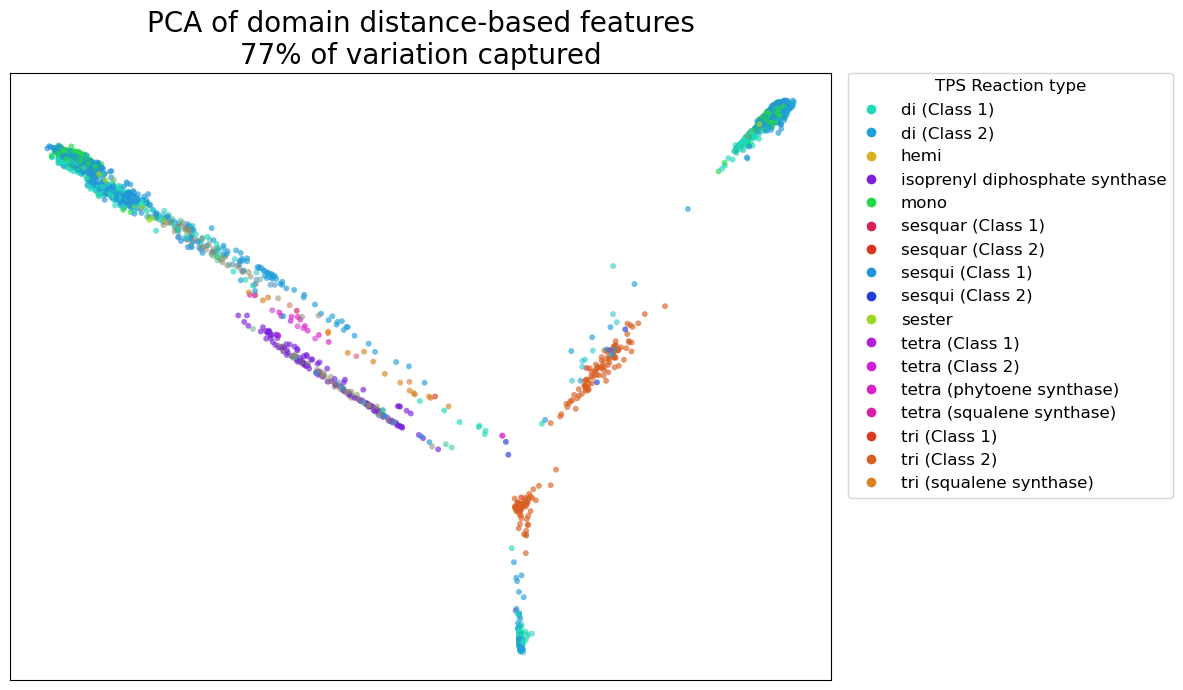

In [225]:
pca_coord_dom, explained_variance = get_pca_analysis(
    domains_dist_matrice,
    dom_reaction_types,
    reaction_types,
    title="PCA of domain distance-based features",
    legend_title="TPS Reaction type",
    # markings=[(dom_2_idx[module_id], dom_2_idx[module_id]) for module_id in [domains[gammas_closest_to_alphas[i]] for i in range(200,250)]],
    # markings=markings
)

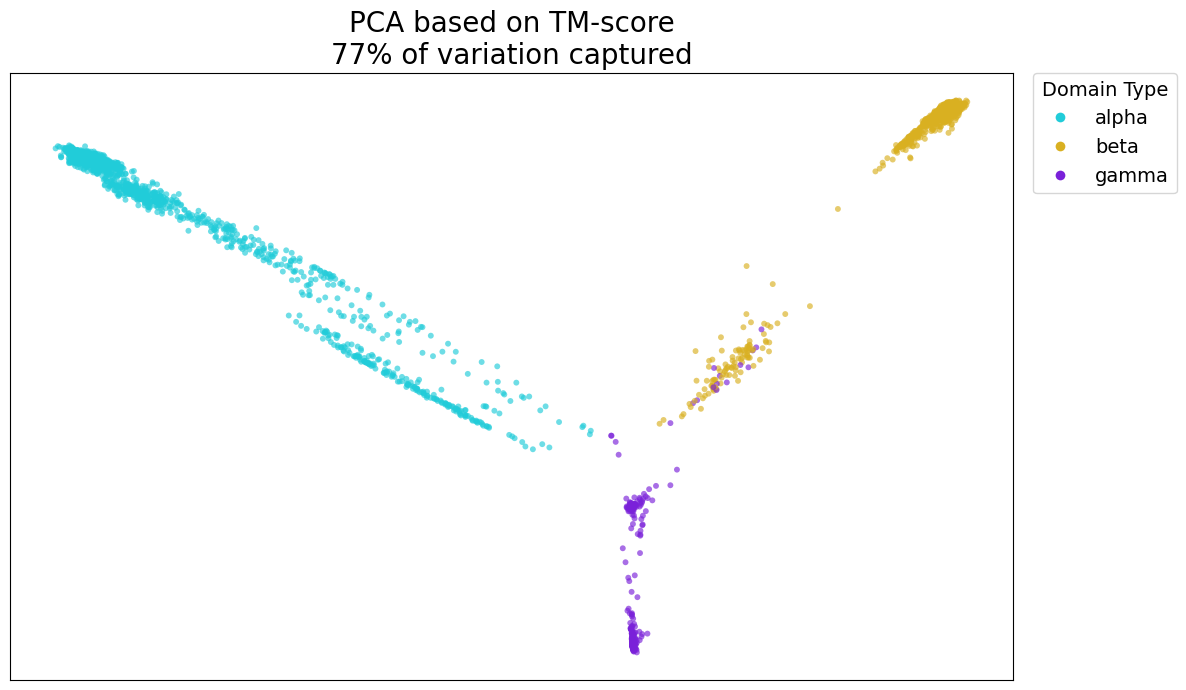

In [226]:
novel_doms_2_conventional_dom_types = {
    "alpha": {"alpha"},
    "beta": {"beta"},
    "gamma": {"gamma"},
    "delta": {"beta"},
    "epsilon": {"gamma"}
}

conventional_dom_types = [novel_doms_2_conventional_dom_types[domain_2_domain_type[dom]] for dom in domains]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    conventional_dom_types,
    ["alpha", "beta", "gamma"],
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
)
plt.show()

# K-Medoid Clustering

  0%|          | 0/13 [00:00<?, ?it/s]

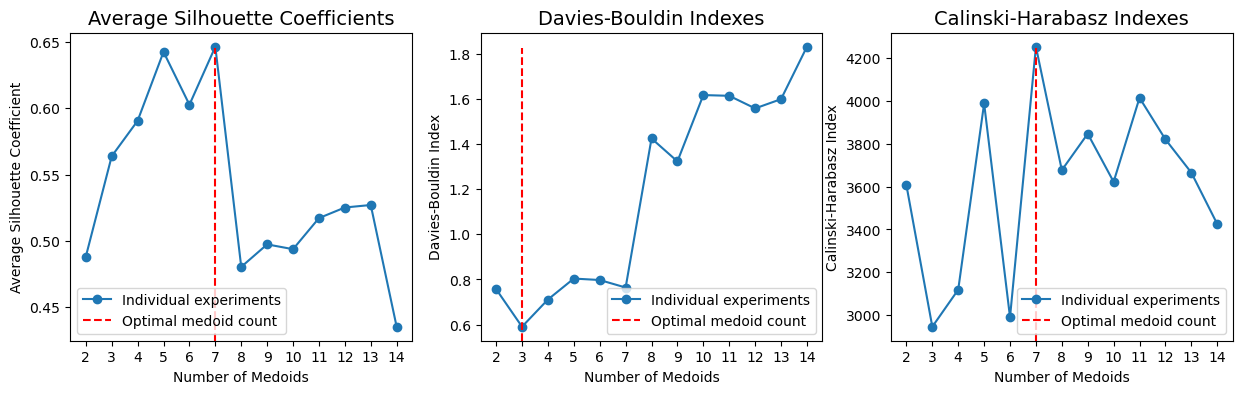

In [227]:
max_range = 15
km_s, silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all = (
    get_k_medoid_clustering(domains_dist_matrice, max_range, 10000, 12)
)
n_medoids_best = plot_optimal_num_medoid_selection(
    silhouette_avg_all, davies_bouldin_all, calinski_harabasz_all, max_range
)
km = km_s[n_medoids_best - 2]
cluster_labels = km.labels_
    
cluster_label_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_labels)

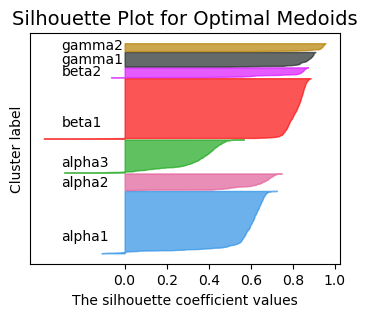

In [228]:
plot_silhouette_analysis(domains_dist_matrice, np.array([cluster_label_2_domain_subtype[l] for l in cluster_labels]))

In [252]:

km = km_s[5 - 2]
cluster_labels = km.labels_
    
cluster_label_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(cluster_labels, domain_labels)

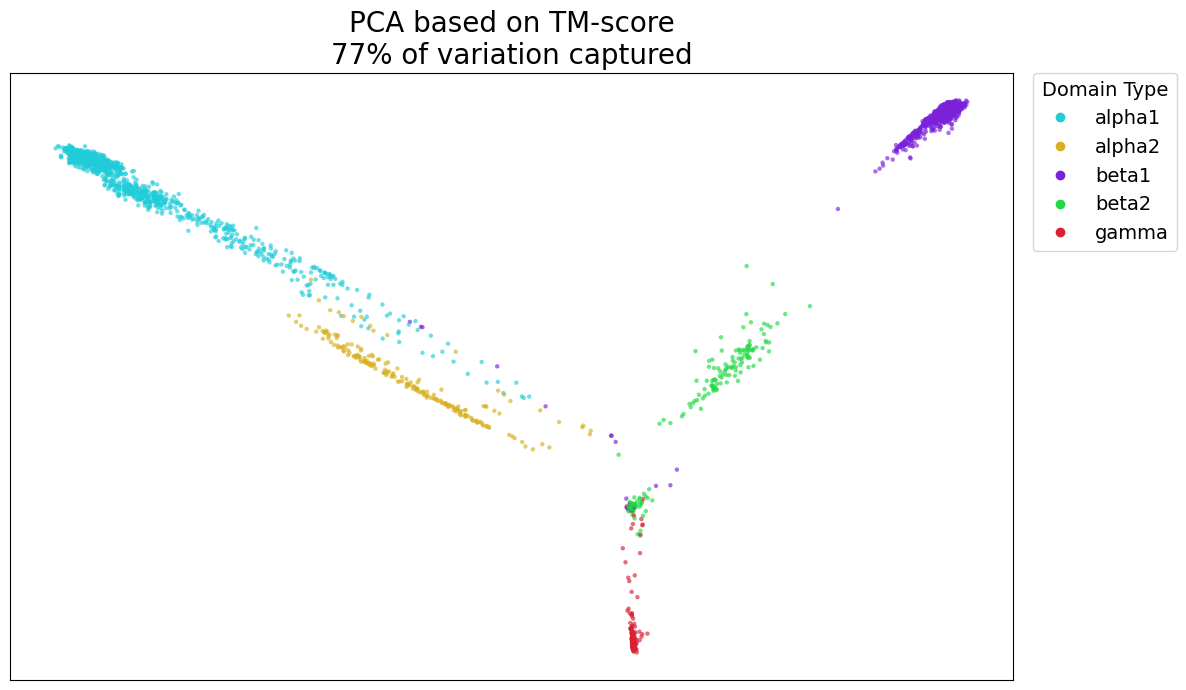

In [253]:
domain_subtypes = [set([cluster_label_2_domain_subtype[l]]) for l in cluster_labels]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    domain_subtypes,
    sorted(cluster_label_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"PCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
    marker_size=10
)
plt.show()

# HDBSCAN Clustering

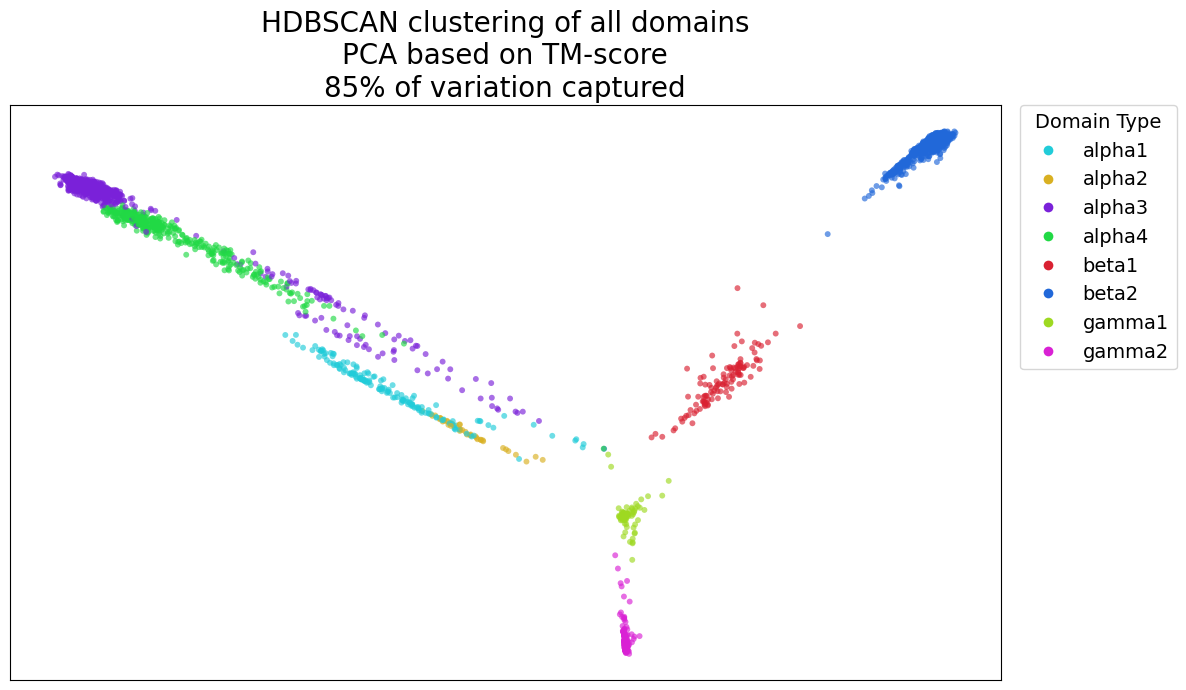

In [ ]:
hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=30
)  # , min_cluster_size=10)
hdbscan_clusterer.fit(domains_dist_matrice)

fill_noise_with_closest_label(
    hdbscan_clusterer.labels_, domains_dist_matrice, n_neighbs=20
)

hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    hdbscan_clusterer.labels_, domain_labels
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    pca_coord_dom,
    [{hdbscan_cluster_id_2_domain_subtype[l]} for l in hdbscan_clusterer.labels_],
    sorted(hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all domains\nPCA based on TM-score\n{sum(explained_variance)*100:.0f}% of variation captured",
)
plt.show()

# Non-Alpha Domains Analysis

In [237]:
non_alpha_clusters_ids = set([i for i,domain_subtype in cluster_label_2_domain_subtype.items() if "alpha" not in domain_subtype])
non_alpha_idxs = [i for i, label in enumerate(km.labels_) if label in non_alpha_clusters_ids]
non_alpha_dist_matrice = domains_dist_matrice[non_alpha_idxs, :][:, non_alpha_idxs]
non_alpha_domains = [domains[i] for i in non_alpha_idxs]
non_alpha_domain_types = [cluster_label_2_domain_subtype[cluster_labels[i]] for i in non_alpha_idxs]
non_alpha_reaction_types = [dom_reaction_types[i] for i in non_alpha_idxs]
non_alpha_sequences = [dom_seq_ids[i] for i in non_alpha_idxs]
non_alpha_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(non_alpha_sequences)]
non_alpha_reaction_types_all = non_alpha_martsDB.reaction_type.unique()

## PCA Analysis

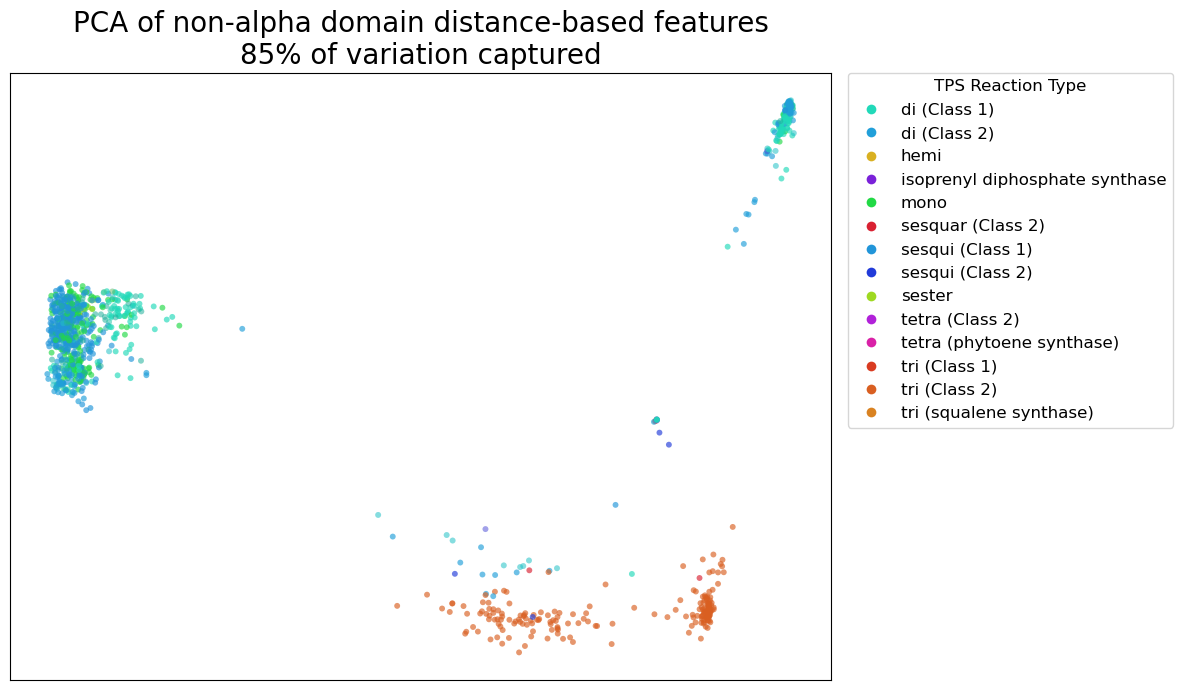

In [238]:
non_alpha_pca_coord_dom, non_alpha_explained_variance = get_pca_analysis(
    non_alpha_dist_matrice,
    non_alpha_reaction_types,
    non_alpha_reaction_types_all,
    title="PCA of non-alpha domain distance-based features",
    legend_title="TPS Reaction Type",
)


## K-Medoid Clustering

  0%|          | 0/18 [00:00<?, ?it/s]

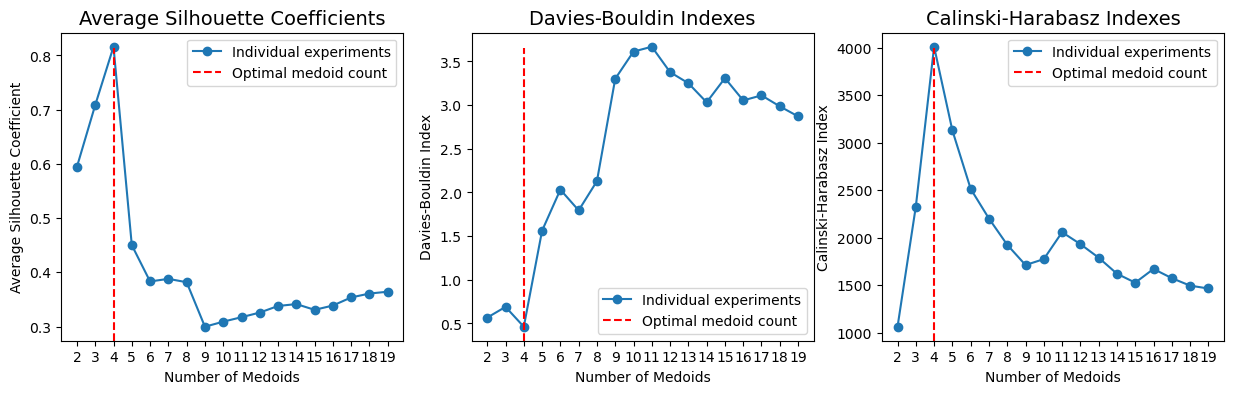

In [239]:
max_range = 20
non_alpha_km_s, non_alpha_silhouette_avg_all, non_alpha_davies_bouldin_all, non_alpha_calinski_harabasz_all = (
    get_k_medoid_clustering(non_alpha_dist_matrice, max_range)
)
non_alpha_n_medoids_best = plot_optimal_num_medoid_selection(
    non_alpha_silhouette_avg_all, non_alpha_davies_bouldin_all, non_alpha_calinski_harabasz_all, max_range
)
non_alpha_km = non_alpha_km_s[non_alpha_n_medoids_best - 2]
non_alpha_cluster_labels = non_alpha_km.labels_
non_alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(non_alpha_cluster_labels, non_alpha_domain_types)

In [240]:
non_alpha_cluster_id_2_domain_subtype

{0: 'beta1', 3: 'gamma2', 2: 'beta2', 1: 'gamma1'}

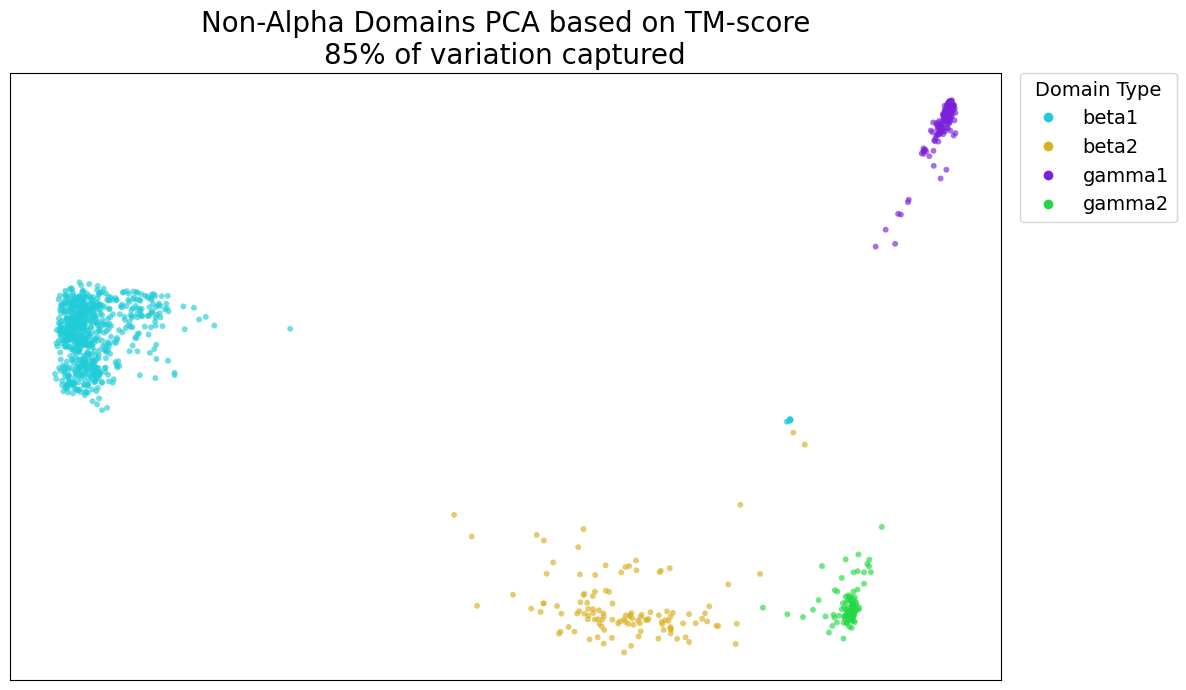

In [241]:
non_alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    non_alpha_cluster_labels, non_alpha_domain_types
)

non_alpha_new_domains = [set([non_alpha_cluster_id_2_domain_subtype[l]]) for l in non_alpha_cluster_labels]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    non_alpha_new_domains,
    sorted(non_alpha_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Non-Alpha Domains PCA based on TM-score\n{sum(non_alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## HDBSCAN Clustering

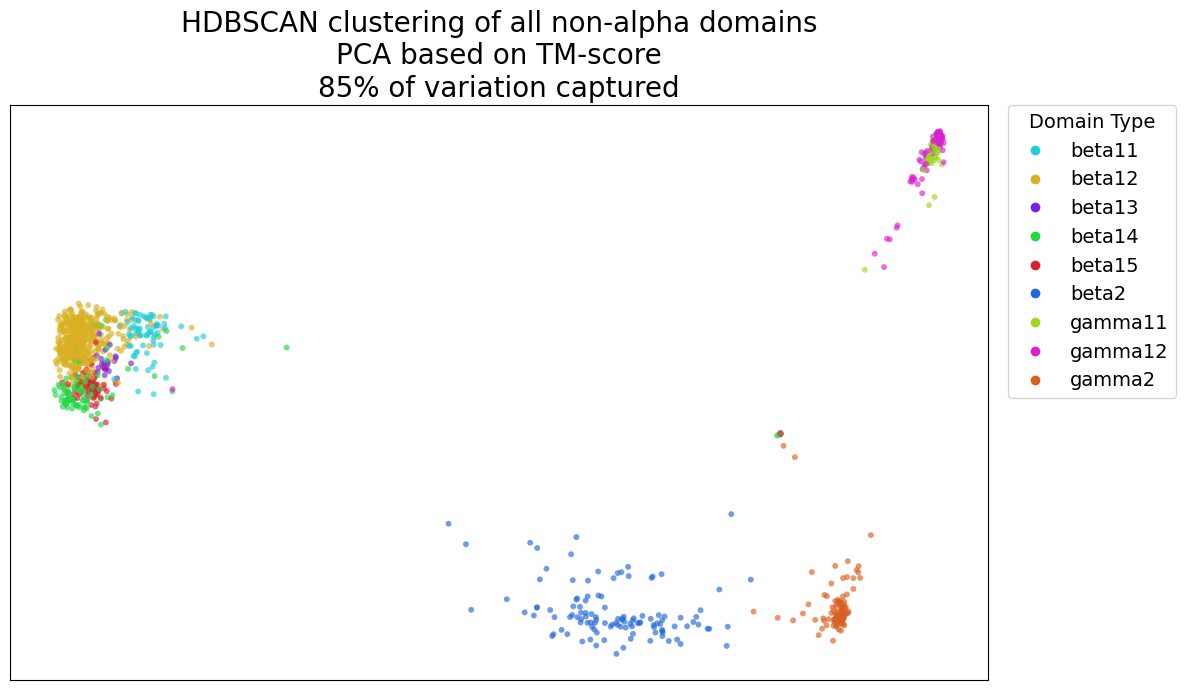

In [257]:
non_alpha_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
non_alpha_hdbscan_clusterer.fit(non_alpha_dist_matrice)

fill_noise_with_closest_label(
    non_alpha_hdbscan_clusterer.labels_, non_alpha_dist_matrice, n_neighbs=11
)

non_alpha_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    non_alpha_hdbscan_clusterer.labels_, non_alpha_domain_types
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    non_alpha_pca_coord_dom,
    [{non_alpha_hdbscan_cluster_id_2_domain_subtype[l]} for l in non_alpha_hdbscan_clusterer.labels_],
    sorted(non_alpha_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all non-alpha domains\nPCA based on TM-score\n{sum(non_alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

# Alpha Domains Analysis

In [244]:
alpha_clusters_ids = set([i for i,domain_subtype in cluster_label_2_domain_subtype.items() if "alpha" in domain_subtype])
alpha_idxs = [i for i, label in enumerate(km.labels_) if label in alpha_clusters_ids]
alpha_dist_matrice = domains_dist_matrice[alpha_idxs, :][:, alpha_idxs]
alpha_domains = [domains[i] for i in alpha_idxs]
alpha_domain_types = [cluster_label_2_domain_subtype[cluster_labels[i]] for i in alpha_idxs]
alpha_reaction_types = [dom_reaction_types[i] for i in alpha_idxs]
alpha_sequences = [dom_seq_ids[i] for i in alpha_idxs]
alpha_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha_sequences)]
alpha_reaction_types_all = alpha_martsDB.reaction_type.unique()

## PCA Analysis

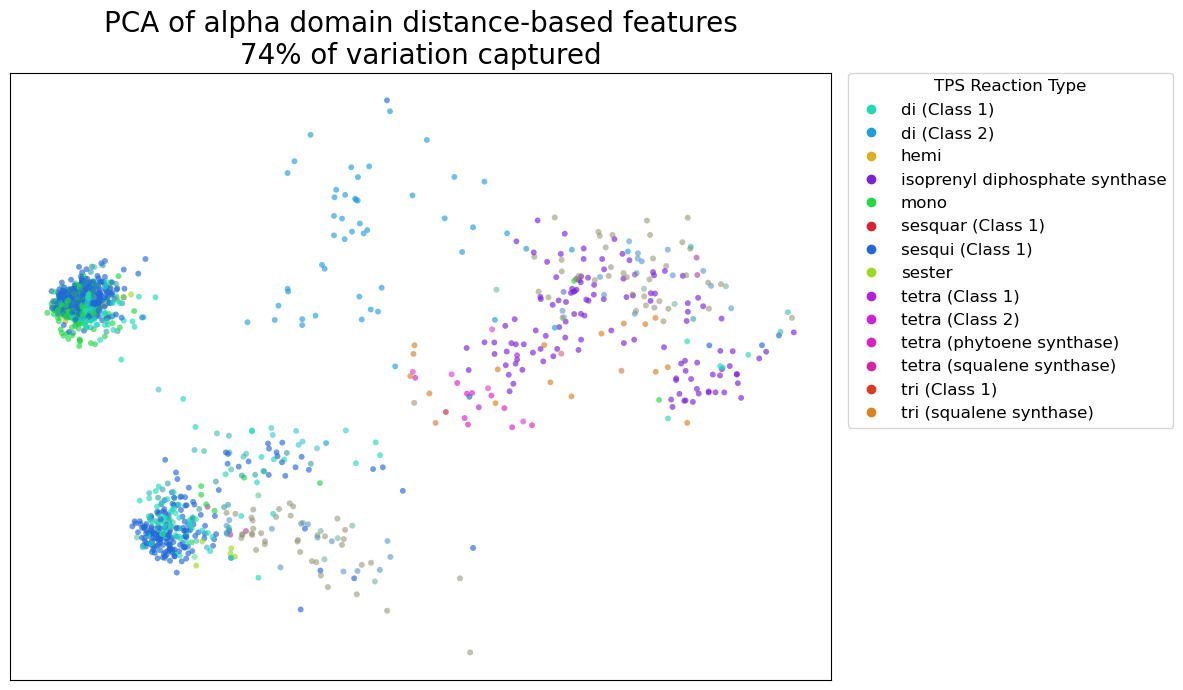

In [245]:
alpha_pca_coord_dom, alpha_explained_variance = get_pca_analysis(
    alpha_dist_matrice,
    alpha_reaction_types,
    alpha_reaction_types_all,
    title="PCA of alpha domain distance-based features",
    legend_title="TPS Reaction Type",
)


## K-Medoid Clustering

  0%|          | 0/18 [00:00<?, ?it/s]

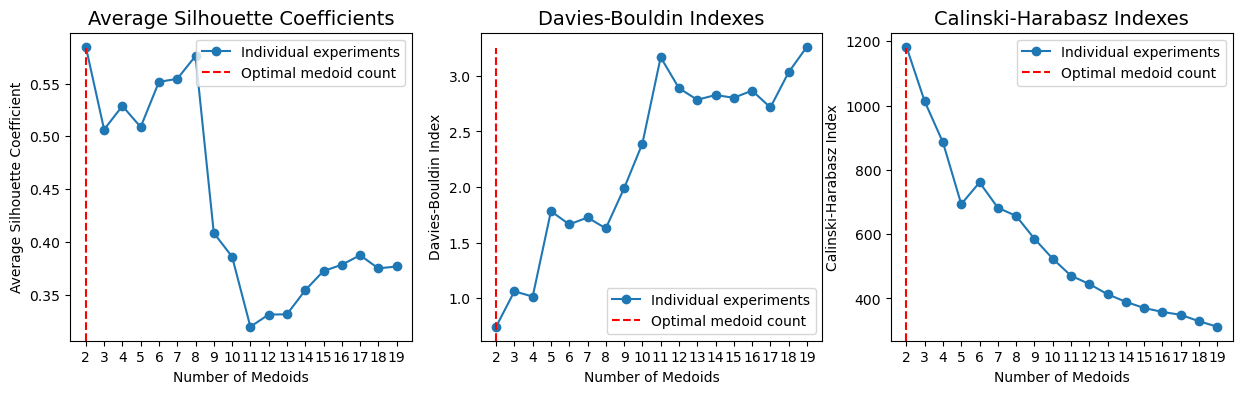

In [246]:
max_range = 20
alpha_km_s, alpha_silhouette_avg_all, alpha_davies_bouldin_all, alpha_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha_dist_matrice, max_range)
)
alpha_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha_silhouette_avg_all, alpha_davies_bouldin_all, alpha_calinski_harabasz_all, max_range
)
alpha_km = alpha_km_s[alpha_n_medoids_best - 2]
alpha_cluster_labels = alpha_km.labels_

alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha_cluster_labels, alpha_domain_types)

In [250]:
alpha_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha_cluster_labels, len(alpha_cluster_labels)*["alpha"])

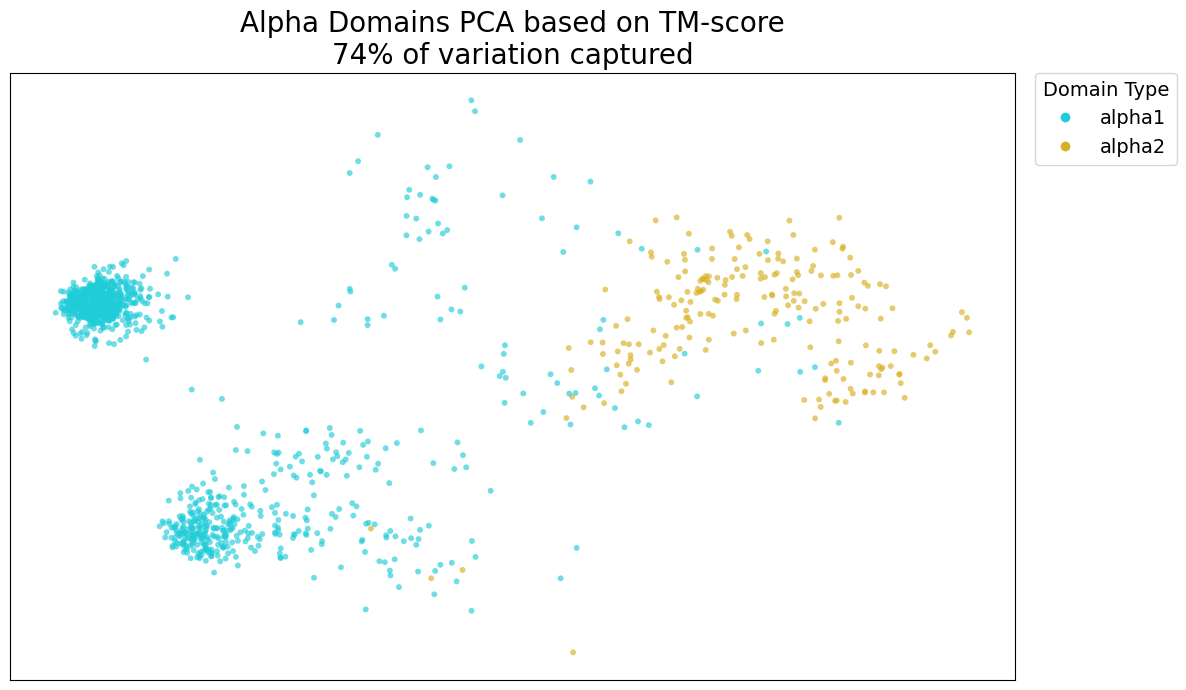

In [251]:
alpha_new_domains = [set([alpha_cluster_id_2_domain_subtype[l]]) for l in alpha_cluster_labels]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    alpha_new_domains,
    sorted(alpha_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha Domains PCA based on TM-score\n{sum(alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

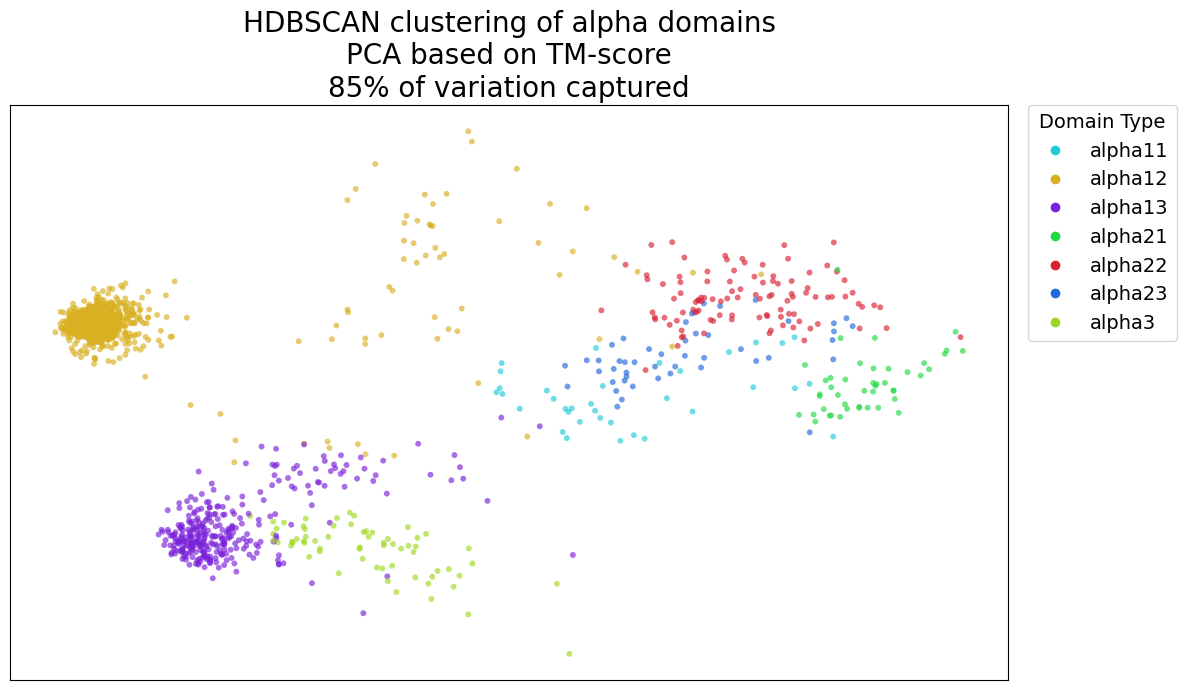

In [258]:
alpha_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
alpha_hdbscan_clusterer.fit(alpha_dist_matrice)

fill_noise_with_closest_label(
    alpha_hdbscan_clusterer.labels_, alpha_dist_matrice, n_neighbs=20
)

alpha_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha_hdbscan_clusterer.labels_, alpha_domain_types
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha_pca_coord_dom,
    [{alpha_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha_hdbscan_clusterer.labels_],
    sorted(alpha_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of alpha domains\nPCA based on TM-score\n{sum(non_alpha_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

In [23]:
alpha_domain_subtype_2_cluster_id = {v:k for k,v in alpha_cluster_id_2_domain_subtype.items()}

## Alpha-1 Domains Analysis

In [24]:
alpha1_clusters_ids = set([alpha_domain_subtype_2_cluster_id["alpha1"]])
alpha1_idxs = [i for i, label in enumerate(alpha_km.labels_) if label in alpha1_clusters_ids]
alpha1_dist_matrice = alpha_dist_matrice[alpha1_idxs, :][:, alpha1_idxs]
alpha1_domains = [alpha_domains[i] for i in alpha1_idxs]
alpha1_domain_types = ["alpha1" for i in alpha1_idxs]
alpha1_reaction_types = [alpha_reaction_types[i] for i in alpha1_idxs]
alpha1_sequences = [alpha_sequences[i] for i in alpha1_idxs]
alpha1_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha1_sequences)]
alpha1_reaction_types_all = alpha1_martsDB.reaction_type.unique()

## PCA Analysis

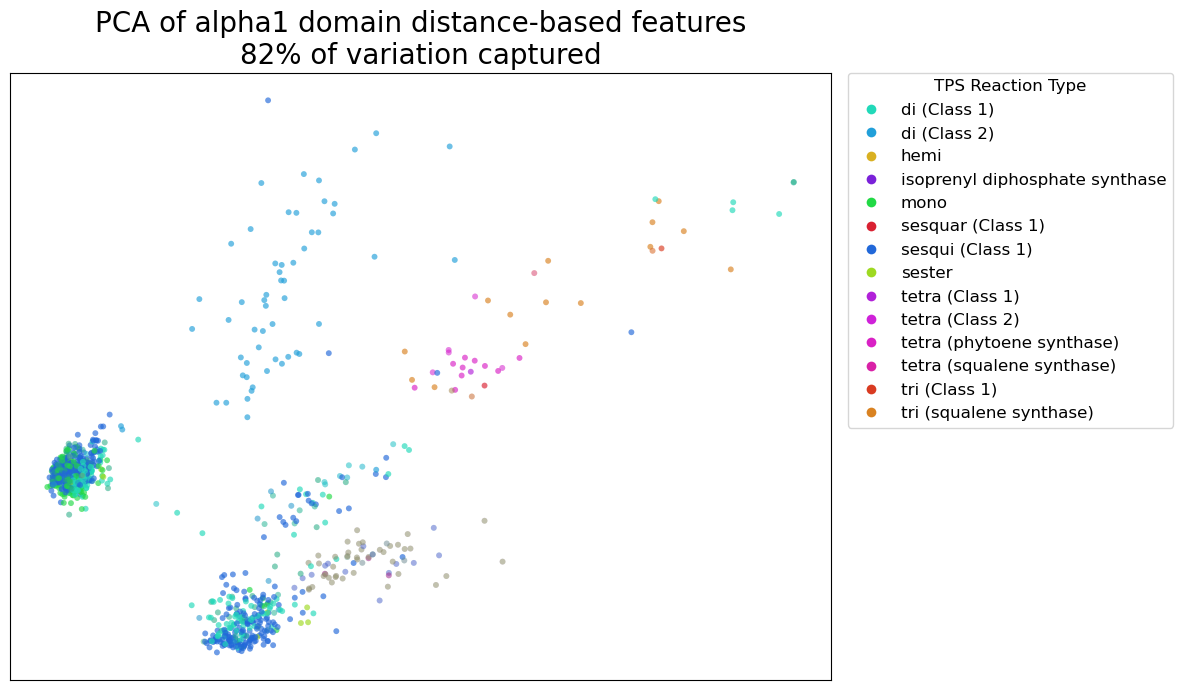

In [25]:
alpha1_pca_coord_dom, alpha1_explained_variance = get_pca_analysis(
    alpha1_dist_matrice,
    alpha1_reaction_types,
    alpha1_reaction_types_all,
    title="PCA of alpha1 domain distance-based features",
    legend_title="TPS Reaction Type",
)


## K-Medoid Clustering

  0%|          | 0/18 [00:00<?, ?it/s]

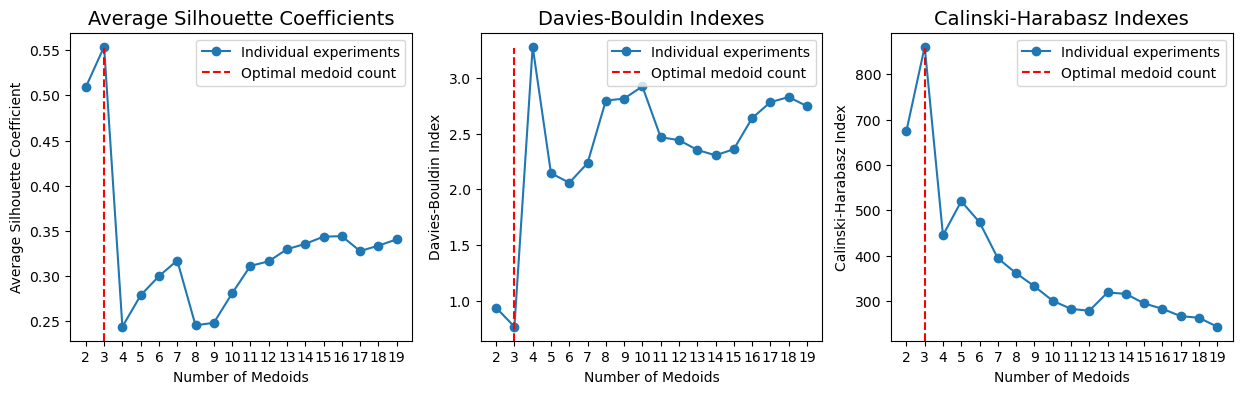

In [ ]:
max_range = 20
alpha1_km_s, alpha1_silhouette_avg_all, alpha1_davies_bouldin_all, alpha1_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha1_dist_matrice, max_range)
)
alpha1_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha1_silhouette_avg_all, alpha1_davies_bouldin_all, alpha1_calinski_harabasz_all, max_range
)
alpha1_km = alpha1_km_s[alpha1_n_medoids_best - 2]
alpha1_cluster_labels = alpha1_km.labels_
alpha1_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha1_cluster_labels, alpha1_domain_types, level=2)

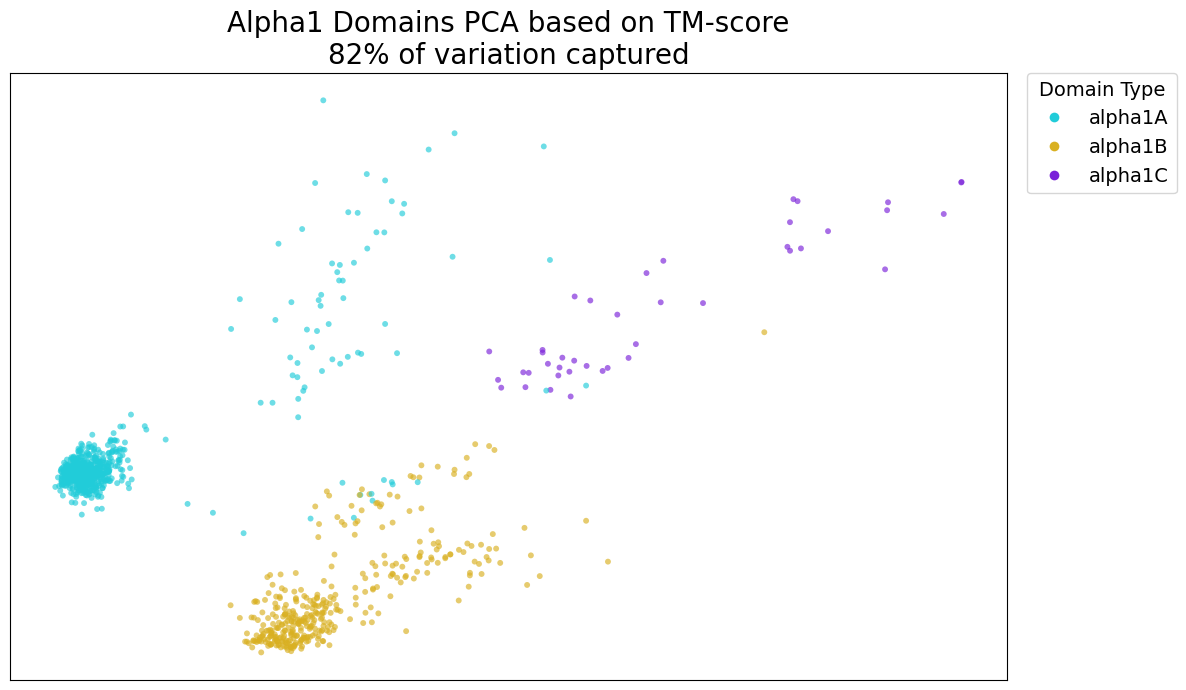

In [27]:
alpha1_new_domains = [set([alpha1_cluster_id_2_domain_subtype[l]]) for l in alpha1_cluster_labels]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha1_pca_coord_dom,
    alpha1_new_domains,
    sorted(alpha1_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha1 Domains PCA based on TM-score\n{sum(alpha1_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## HDBSCAN Clustering

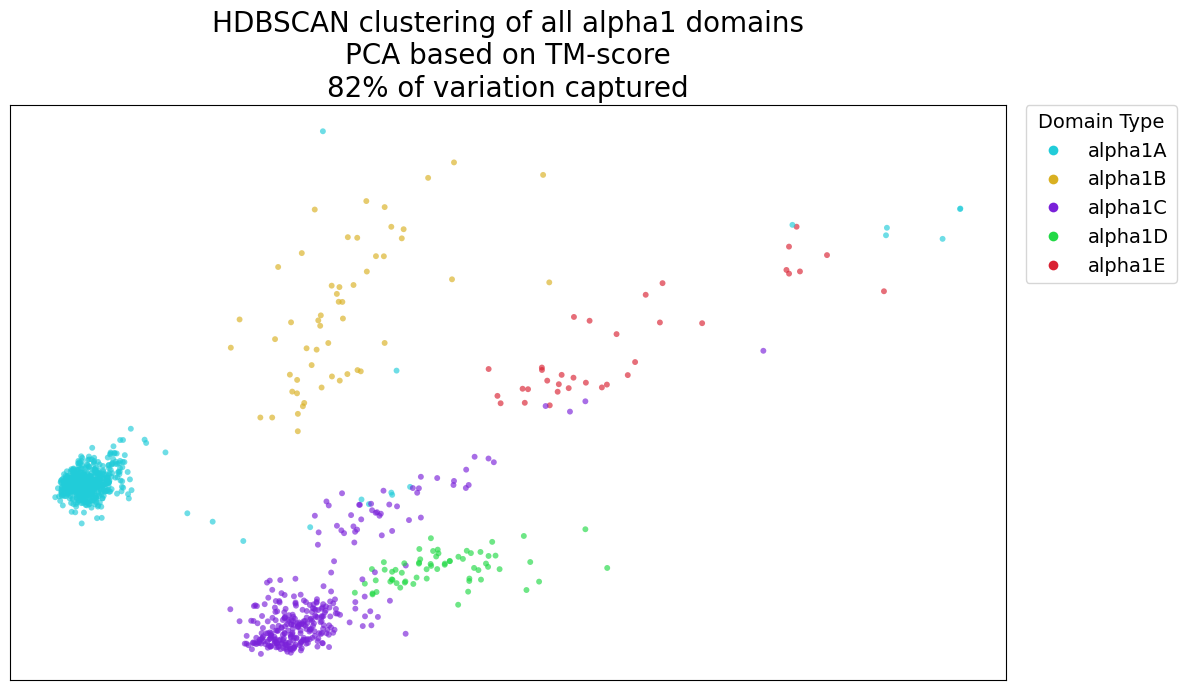

In [ ]:
alpha1_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=20
)  # , min_cluster_size=10)
alpha1_hdbscan_clusterer.fit(alpha1_dist_matrice)

fill_noise_with_closest_label(
    alpha1_hdbscan_clusterer.labels_, alpha1_dist_matrice, n_neighbs=11
)


alpha1_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha1_hdbscan_clusterer.labels_, alpha1_domain_types, level=2
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha1_pca_coord_dom,
    [{alpha1_hdbscan_cluster_id_2_domain_subtype[l]} for l in alpha1_hdbscan_clusterer.labels_],
    sorted(alpha1_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha1 domains\nPCA based on TM-score\n{sum(alpha1_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## Alpha-2 Domains Analysis

In [30]:
alpha2_clusters_ids = set([alpha_domain_subtype_2_cluster_id["alpha2"]])
alpha2_idxs = [i for i, label in enumerate(alpha_km.labels_) if label in alpha2_clusters_ids]
alpha2_dist_matrice = alpha_dist_matrice[alpha2_idxs, :][:, alpha2_idxs]
alpha2_domains = [alpha_domains[i] for i in alpha2_idxs]
alpha2_domain_types = ["alpha2" for i in alpha2_idxs]
alpha2_reaction_types = [alpha_reaction_types[i] for i in alpha2_idxs]
alpha2_sequences = [alpha_sequences[i] for i in alpha2_idxs]
alpha2_martsDB = martsDB[martsDB.Enzyme_marts_ID.isin(alpha2_sequences)]
alpha2_reaction_types_all = alpha2_martsDB.reaction_type.unique()

## PCA Analysis

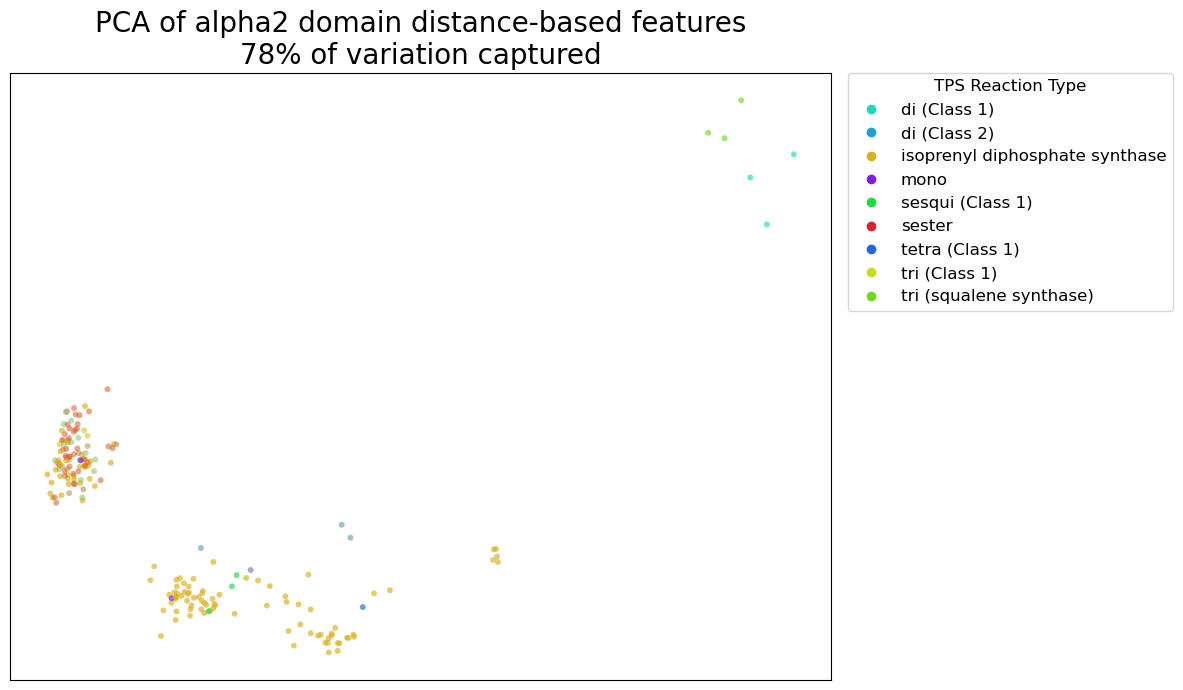

In [31]:
alpha2_pca_coord_dom, alpha2_explained_variance = get_pca_analysis(
    alpha2_dist_matrice,
    alpha2_reaction_types,
    alpha2_reaction_types_all,
    title="PCA of alpha2 domain distance-based features",
    legend_title="TPS Reaction Type",
)


## K-Medoid Clustering

  0%|          | 0/18 [00:00<?, ?it/s]

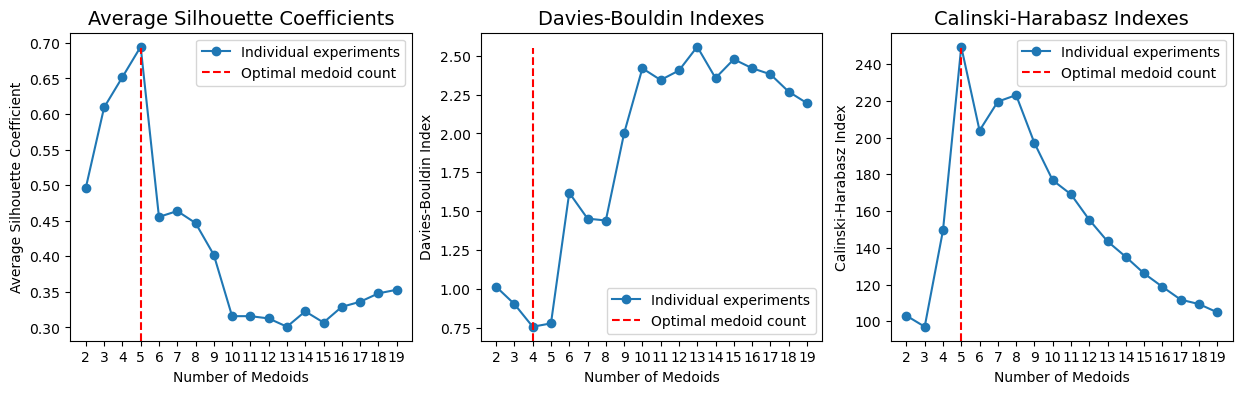

In [ ]:
max_range = 20
alpha2_km_s, alpha2_silhouette_avg_all, alpha2_davies_bouldin_all, alpha2_calinski_harabasz_all = (
    get_k_medoid_clustering(alpha2_dist_matrice, max_range)
)
alpha2_n_medoids_best = plot_optimal_num_medoid_selection(
    alpha2_silhouette_avg_all, alpha2_davies_bouldin_all, alpha2_calinski_harabasz_all, max_range
)
alpha2_km = alpha2_km_s[alpha2_n_medoids_best - 2]
alpha2_cluster_labels = alpha2_km.labels_

alpha2_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(alpha2_cluster_labels, alpha2_domain_types, level=2)

In [ ]:
alpha2_km = alpha2_km_s[5 - 2]
alpha2_cluster_labels = alpha2_km.labels_
(
    alpha2_km_cluster_id_to_domains,
    alpha2_domain_type_2_km_cluster_ids,
    alpha2_cluster_id_2_domain_subtype
) = get_cluster_label_to_domain_subtype_mappings(alpha2_cluster_labels, alpha2_domain_types, level=2)

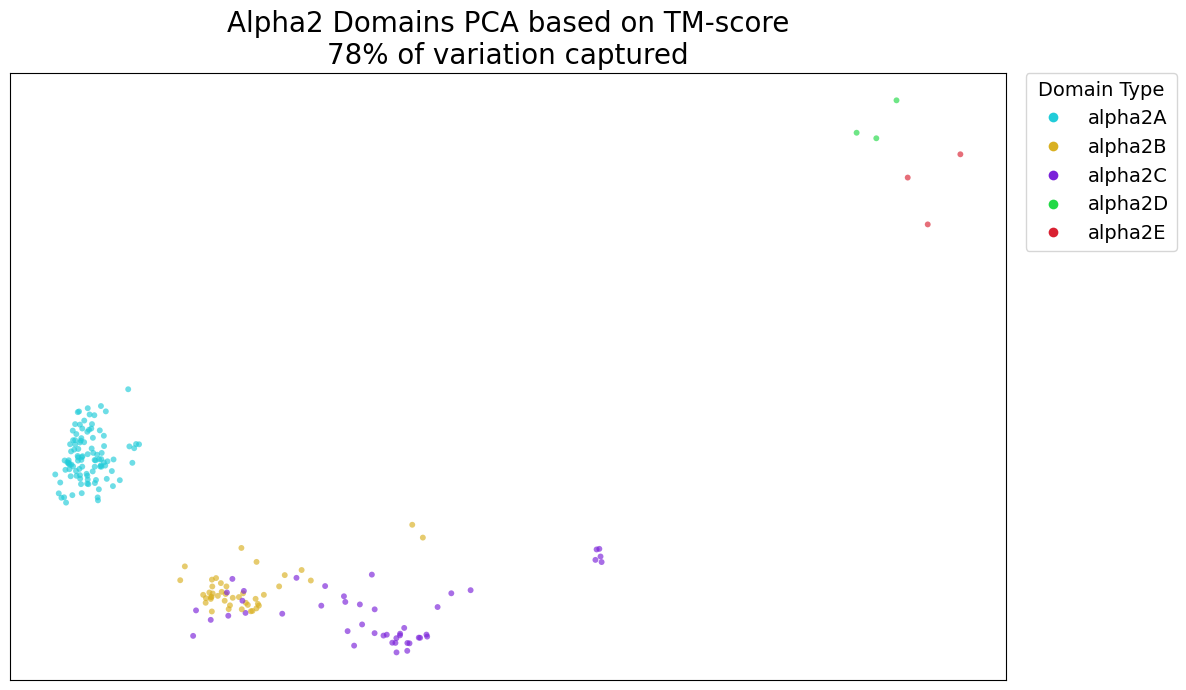

In [58]:
alpha2_new_domains = [set([alpha2_cluster_id_2_domain_subtype[l]]) for l in alpha2_cluster_labels]

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha2_pca_coord_dom,
    alpha2_new_domains,
    sorted(alpha2_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"Alpha2 Domains PCA based on TM-score\n{sum(alpha2_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

## HDBSCAN Clustering

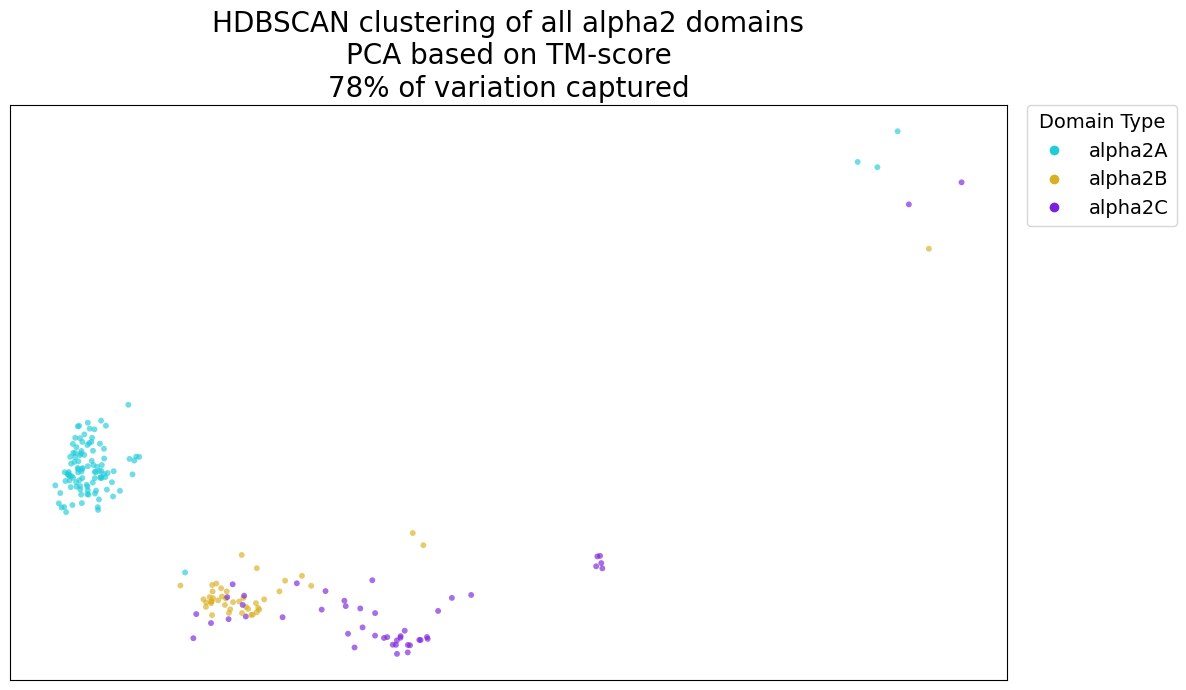

In [ ]:
alpha2_hdbscan_clusterer = hdbscan.HDBSCAN(
    metric="precomputed", min_cluster_size=15
)  # , min_cluster_size=10)
alpha2_hdbscan_clusterer.fit(alpha2_dist_matrice)

fill_noise_with_closest_label(
    alpha2_hdbscan_clusterer.labels_, alpha2_dist_matrice, n_neighbs=11
)

alpha2_hdbscan_cluster_id_2_domain_subtype = get_cluster_label_to_domain_subtype_mappings(
    alpha2_hdbscan_clusterer.labels_, alpha2_domain_types, level=2
)

fig, ax, cmap = plot_multilabel_pca_scatter_all_label_legend(
    alpha2_pca_coord_dom,
    [
        {alpha2_hdbscan_cluster_id_2_domain_subtype[l]}
        for l in alpha2_hdbscan_clusterer.labels_
    ],
    sorted(alpha2_hdbscan_cluster_id_2_domain_subtype.values()),
    group_key_fn=lambda s: s,  # or s.split("_")[0]
    legend_title="Domain Type",
    title=f"HDBSCAN clustering of all alpha2 domains\nPCA based on TM-score\n{sum(alpha2_explained_variance)*100:.0f}% of variation captured",
)
plt.show()

# Finalise and Analyse Domain Subtypes

In [92]:
domain_module_id_2_domain_subtype = {}

In [93]:
for idx, domain in enumerate(non_alpha_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = (
            non_alpha_hdbscan_cluster_id_2_domain_subtype[
                non_alpha_hdbscan_clusterer.labels_[idx]
            ]
        )
    else:
        raise ValueError(f"Domain {domain} already has a subtype assigned: {domain_module_id_2_domain_subtype[domain]}. This should not happen.")

In [94]:
for idx, domain in enumerate(alpha1_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = (
            alpha1_cluster_id_2_domain_subtype[
                alpha1_km.labels_[idx]
            ]
        )

In [95]:
for idx, domain in enumerate(alpha2_domains):
    if domain not in domain_module_id_2_domain_subtype:
        domain_module_id_2_domain_subtype[domain] = list(alpha2_new_domains[idx])[0]
    else:
        raise ValueError(f"Domain {domain} already has a subtype assigned: {domain_module_id_2_domain_subtype[domain]}. This should not happen.")

## Finalise the Domain Subtypes

In [96]:
set(domain_module_id_2_domain_subtype.values())

{'alpha1A',
 'alpha1B',
 'alpha1C',
 'alpha2A',
 'alpha2B',
 'alpha2C',
 'alpha2D',
 'alpha2E',
 'beta',
 'delta',
 'epsilon',
 'gamma1',
 'gamma2'}

In [97]:
assert set(domain_module_id_2_domain_subtype.keys()) == set(domains)

In [98]:
pickle.dump(domain_module_id_2_domain_subtype, open("./domain_module_id_2_domain_type.pkl", "wb"))

## Analyse Domain Subtypes

In [99]:
domain_module_id_2_domain_subtype = pickle.load(open("./domain_module_id_2_domain_type.pkl", "rb"))
martsDB = martsDB.iloc[:4030]
domain_module_id_2_seq_id = {
    domain: "_".join(domain.split("_")[:2]) for domain in domain_module_id_2_domain_subtype.keys()
}
seq_id_2_domains = defaultdict(set)
for domain, seq_id in domain_module_id_2_seq_id.items():
    seq_id_2_domains[seq_id].add(domain)
seq_id_2_domain_subtypes = defaultdict(set)
for domain, domain_subtype in domain_module_id_2_domain_subtype.items():
    seq_id = domain_module_id_2_seq_id[domain]
    seq_id_2_domain_subtypes[seq_id].add(domain_subtype)

### Kingdoms

In [100]:
assert set(martsDB.Kingdom.unique()) == set(['Plants', 'Fungi', 'Bacteria', 'Animals', 'Protists', 'Archaea','Viruses'])
kingdom_2_color = dict(zip(['Plants', 'Fungi', 'Bacteria', 'Animals', 'Protists', 'Archaea','Viruses'], 
                           ['#20E478', '#F1A978', '#FFD966', '#FF4343', '#5B9BD5', '#EA8FBF', '#2F5597']))


kingdom_2_domain_configs: dict[str, list[tuple[tuple[str], int, float]]] = {}
domain_config_2_kingdoms: dict[tuple[str], list[tuple[str, int, float]]] = {}
for kingdom in set(martsDB.Kingdom.unique()):
    seq_ids = martsDB[martsDB.Kingdom == kingdom].Enzyme_marts_ID.unique()
    domain_configs = [tuple(sorted(seq_id_2_domain_subtypes[seq_id])) for seq_id in seq_ids]
    domain_config_ctr = Counter(domain_configs)
    kingdom_2_domain_configs[kingdom] = [(domain_config, count, count / len(domain_configs)) for domain_config, count in domain_config_ctr.items()]
    
for domain_config in set([config for configs in kingdom_2_domain_configs.values() for config, _, _ in configs]):
    kingdoms_with_config = [(kingdom, count) for kingdom, configs in kingdom_2_domain_configs.items() for config, count, _ in configs if config == domain_config]
    kingdoms_with_config = sorted(kingdoms_with_config, key=lambda x: x[1], reverse=True)
    kingdoms_with_config = [(kingdom, count, count / sum(count for _, count in kingdoms_with_config)) for kingdom, count in kingdoms_with_config]
    domain_config_2_kingdoms[domain_config] = kingdoms_with_config
import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(domain_config_2_kingdoms)

{   ('alpha1A',): [   ('Fungi', 5, 0.3333333333333333),
                      ('Bacteria', 4, 0.26666666666666666),
                      ('Plants', 4, 0.26666666666666666),
                      ('Animals', 2, 0.13333333333333333)],
    ('alpha1A', 'beta'): [('Plants', 527, 1.0)],
    ('alpha1A', 'beta', 'gamma1'): [('Plants', 93, 1.0)],
    ('alpha1A', 'beta', 'gamma2'): [('Plants', 53, 1.0)],
    ('alpha1A', 'delta', 'gamma1'): [   ('Fungi', 2, 0.6666666666666666),
                                        ('Bacteria', 1, 0.3333333333333333)],
    ('alpha1A', 'gamma2'): [('Plants', 1, 1.0)],
    ('alpha1B',): [   ('Fungi', 119, 0.41901408450704225),
                      ('Bacteria', 110, 0.3873239436619718),
                      ('Plants', 20, 0.07042253521126761),
                      ('Protists', 18, 0.06338028169014084),
                      ('Animals', 16, 0.056338028169014086),
                      ('Viruses', 1, 0.0035211267605633804)],
    ('alpha1B', 'alpha2A'): [('Fungi'

In [101]:
reaction_type_2_domain_configs: dict[str, list[tuple[tuple[str], int, float]]] = {}
domain_config_2_reaction_type: dict[tuple[str], list[tuple[str, int, float]]] = {}
for reaction_type in set(martsDB.reaction_type.unique()):
    seq_ids = martsDB[martsDB.reaction_type == reaction_type].Enzyme_marts_ID.unique()
    domain_configs = [tuple(sorted(seq_id_2_domain_subtypes[seq_id])) for seq_id in seq_ids]
    domain_config_ctr = Counter(domain_configs)
    reaction_type_2_domain_configs[reaction_type] = [(domain_config, count, count / len(domain_configs)) for domain_config, count in domain_config_ctr.items()]
    
for domain_config in set([config for configs in reaction_type_2_domain_configs.values() for config, _, _ in configs]):
    reaction_type_with_config = [(reaction_type, count) for reaction_type, configs in reaction_type_2_domain_configs.items() for config, count, _ in configs if config == domain_config]
    reaction_type_with_config = sorted(reaction_type_with_config, key=lambda x: x[1], reverse=True)
    reaction_type_with_config = [(reaction_type, count, count / sum(count for _, count in reaction_type_with_config)) for reaction_type, count in reaction_type_with_config]
    domain_config_2_reaction_type[domain_config] = reaction_type_with_config
import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(domain_config_2_reaction_type)

{   ('alpha1A',): [   ('sesqui (Class 1)', 10, 0.47619047619047616),
                      ('di (Class 1)', 4, 0.19047619047619047),
                      ('sesquar (Class 1)', 2, 0.09523809523809523),
                      ('mono', 2, 0.09523809523809523),
                      ('tri (Class 1)', 1, 0.047619047619047616),
                      ('sester', 1, 0.047619047619047616),
                      ('di (Class 2)', 1, 0.047619047619047616)],
    ('alpha1A', 'beta'): [   ('sesqui (Class 1)', 334, 0.561344537815126),
                             ('mono', 229, 0.38487394957983195),
                             ('di (Class 1)', 25, 0.04201680672268908),
                             ('hemi', 4, 0.0067226890756302525),
                             ('sester', 3, 0.005042016806722689)],
    ('alpha1A', 'beta', 'gamma1'): [   ('di (Class 2)', 71, 0.6228070175438597),
                                       ('di (Class 1)', 31, 0.2719298245614035),
                                       (   's